###Imports

In [281]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader
import math

###Data Loading

In [282]:
data=pd.read_csv('/content/NVDIA_DATA.csv')

In [283]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    2514 non-null   int64  
 1   Date          2514 non-null   object 
 2   Volume        2514 non-null   float64
 3   Open          2514 non-null   float64
 4   High          2514 non-null   float64
 5   Low           2514 non-null   float64
 6   Close         2514 non-null   float64
 7   SMA_20        2495 non-null   float64
 8   SMA_50        2465 non-null   float64
 9   SMA_200       2315 non-null   float64
 10  EMA_20        2514 non-null   float64
 11  EMA_50        2514 non-null   float64
 12  EMA_200       2514 non-null   float64
 13  MACD_Line     2514 non-null   float64
 14  MACD_Signal   2514 non-null   float64
 15  MACD_Hist     2514 non-null   float64
 16  RSI_7         2508 non-null   float64
 17  RSI_14        2501 non-null   float64
 18  RSI_21        2494 non-null 

In [284]:
data.drop('Unnamed: 0',axis=1,inplace=True)
data['Date']=data['Date'].astype('datetime64[ns]')

In [285]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 31 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          2514 non-null   datetime64[ns]
 1   Volume        2514 non-null   float64       
 2   Open          2514 non-null   float64       
 3   High          2514 non-null   float64       
 4   Low           2514 non-null   float64       
 5   Close         2514 non-null   float64       
 6   SMA_20        2495 non-null   float64       
 7   SMA_50        2465 non-null   float64       
 8   SMA_200       2315 non-null   float64       
 9   EMA_20        2514 non-null   float64       
 10  EMA_50        2514 non-null   float64       
 11  EMA_200       2514 non-null   float64       
 12  MACD_Line     2514 non-null   float64       
 13  MACD_Signal   2514 non-null   float64       
 14  MACD_Hist     2514 non-null   float64       
 15  RSI_7         2508 non-null   float64 

In [286]:
data.tail()

,Date,Volume,Open,High,Low,Close,SMA_20,SMA_50,SMA_200,EMA_20,EMA_50,EMA_200,MACD_Line,MACD_Signal,MACD_Hist,RSI_7,RSI_14,RSI_21,ROC_12,ATR_14,BB_Middle_20,BB_Upper_20,BB_Lower_20,StochK_14,StochD_14,KDJ_K_14,KDJ_D_14,KDJ_J_14,OBV,CMF_20,NADAQ CLOSE
2509,2015-09-14,192465440.0,0.5690,0.5707,0.5643,0.5673,0.602345,0.675332,0.829914,0.604501,0.659822,0.942186,-0.030778,-0.032538,0.001761,24.606148,26.150403,28.695352,-7.935735,0.019317,0.602345,0.662168,0.542522,15.447813,19.072245,15.447813,19.072245,8.198949,-1.171232e+11,0.373669,4805.76
2510,2015-09-11,301577320.0,0.5583,0.5700,0.5559,0.5663,0.598070,0.670962,0.827008,0.600863,0.656154,0.938446,-0.030140,-0.032058,0.001919,24.042871,25.914837,28.540763,-4.470310,0.018944,0.598070,0.655171,0.540969,14.933453,16.987357,14.933453,16.987357,10.825647,-1.174248e+11,0.376132,4822.34
2511,2015-09-10,357075840.0,0.5525,0.5715,0.5499,0.5645,0.593580,0.666692,0.824176,0.597400,0.652560,0.934725,-0.029440,-0.031535,0.002094,22.940082,25.470082,28.253092,-3.090129,0.019134,0.593580,0.645994,0.541166,17.933649,16.104972,17.933649,16.104972,21.591003,-1.177819e+11,0.344721,4796.25
2512,2015-09-09,289385960.0,0.5687,0.5735,0.5545,0.5558,0.588845,0.662292,0.821239,0.593438,0.648765,0.930955,-0.029251,-0.031078,0.001827,18.226051,23.381388,26.878209,-5.844486,0.019124,0.588845,0.636502,0.541188,18.840104,17.235735,18.840104,17.235735,22.048842,-1.180713e+11,0.290126,4756.53
2513,2015-09-08,238338720.0,0.5570,0.5693,0.5548,0.5670,0.585005,0.658432,0.818012,0.590920,0.645559,0.927334,-0.027876,-0.030438,0.002562,37.511952,31.203018,31.391232,-3.242321,0.018794,0.585005,0.625917,0.544093,24.149004,20.307586,24.149004,20.307586,31.831842,-1.178329e+11,0.273791,4811.93


In [287]:
data=data.iloc[::-1].reset_index(drop=True)

In [288]:
data.head()

,Date,Volume,Open,High,Low,Close,SMA_20,SMA_50,SMA_200,EMA_20,EMA_50,EMA_200,MACD_Line,MACD_Signal,MACD_Hist,RSI_7,RSI_14,RSI_21,ROC_12,ATR_14,BB_Middle_20,BB_Upper_20,BB_Lower_20,StochK_14,StochD_14,KDJ_K_14,KDJ_D_14,KDJ_J_14,OBV,CMF_20,NADAQ CLOSE
0,2015-09-08,238338720.0,0.5570,0.5693,0.5548,0.5670,0.585005,0.658432,0.818012,0.590920,0.645559,0.927334,-0.027876,-0.030438,0.002562,37.511952,31.203018,31.391232,-3.242321,0.018794,0.585005,0.625917,0.544093,24.149004,20.307586,24.149004,20.307586,31.831842,-1.178329e+11,0.273791,4811.93
1,2015-09-09,289385960.0,0.5687,0.5735,0.5545,0.5558,0.588845,0.662292,0.821239,0.593438,0.648765,0.930955,-0.029251,-0.031078,0.001827,18.226051,23.381388,26.878209,-5.844486,0.019124,0.588845,0.636502,0.541188,18.840104,17.235735,18.840104,17.235735,22.048842,-1.180713e+11,0.290126,4756.53
2,2015-09-10,357075840.0,0.5525,0.5715,0.5499,0.5645,0.593580,0.666692,0.824176,0.597400,0.652560,0.934725,-0.029440,-0.031535,0.002094,22.940082,25.470082,28.253092,-3.090129,0.019134,0.593580,0.645994,0.541166,17.933649,16.104972,17.933649,16.104972,21.591003,-1.177819e+11,0.344721,4796.25
3,2015-09-11,301577320.0,0.5583,0.5700,0.5559,0.5663,0.598070,0.670962,0.827008,0.600863,0.656154,0.938446,-0.030140,-0.032058,0.001919,24.042871,25.914837,28.540763,-4.470310,0.018944,0.598070,0.655171,0.540969,14.933453,16.987357,14.933453,16.987357,10.825647,-1.174248e+11,0.376132,4822.34
4,2015-09-14,192465440.0,0.5690,0.5707,0.5643,0.5673,0.602345,0.675332,0.829914,0.604501,0.659822,0.942186,-0.030778,-0.032538,0.001761,24.606148,26.150403,28.695352,-7.935735,0.019317,0.602345,0.662168,0.542522,15.447813,19.072245,15.447813,19.072245,8.198949,-1.171232e+11,0.373669,4805.76


In [289]:
data.set_index('Date', inplace=True)
display(data.head())

,Volume,Open,High,Low,Close,SMA_20,SMA_50,SMA_200,EMA_20,EMA_50,EMA_200,MACD_Line,MACD_Signal,MACD_Hist,RSI_7,RSI_14,RSI_21,ROC_12,ATR_14,BB_Middle_20,BB_Upper_20,BB_Lower_20,StochK_14,StochD_14,KDJ_K_14,KDJ_D_14,KDJ_J_14,OBV,CMF_20,NADAQ CLOSE
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-09-08,238338720.0,0.5570,0.5693,0.5548,0.5670,0.585005,0.658432,0.818012,0.590920,0.645559,0.927334,-0.027876,-0.030438,0.002562,37.511952,31.203018,31.391232,-3.242321,0.018794,0.585005,0.625917,0.544093,24.149004,20.307586,24.149004,20.307586,31.831842,-1.178329e+11,0.273791,4811.93
2015-09-09,289385960.0,0.5687,0.5735,0.5545,0.5558,0.588845,0.662292,0.821239,0.593438,0.648765,0.930955,-0.029251,-0.031078,0.001827,18.226051,23.381388,26.878209,-5.844486,0.019124,0.588845,0.636502,0.541188,18.840104,17.235735,18.840104,17.235735,22.048842,-1.180713e+11,0.290126,4756.53
2015-09-10,357075840.0,0.5525,0.5715,0.5499,0.5645,0.593580,0.666692,0.824176,0.597400,0.652560,0.934725,-0.029440,-0.031535,0.002094,22.940082,25.470082,28.253092,-3.090129,0.019134,0.593580,0.645994,0.541166,17.933649,16.104972,17.933649,16.104972,21.591003,-1.177819e+11,0.344721,4796.25
2015-09-11,301577320.0,0.5583,0.5700,0.5559,0.5663,0.598070,0.670962,0.827008,0.600863,0.656154,0.938446,-0.030140,-0.032058,0.001919,24.042871,25.914837,28.540763,-4.470310,0.018944,0.598070,0.655171,0.540969,14.933453,16.987357,14.933453,16.987357,10.825647,-1.174248e+11,0.376132,4822.34
2015-09-14,192465440.0,0.5690,0.5707,0.5643,0.5673,0.602345,0.675332,0.829914,0.604501,0.659822,0.942186,-0.030778,-0.032538,0.001761,24.606148,26.150403,28.695352,-7.935735,0.019317,0.602345,0.662168,0.542522,15.447813,19.072245,15.447813,19.072245,8.198949,-1.171232e+11,0.373669,4805.76


###Pre-Processing

In [290]:
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

In [291]:
data.shape

(2315, 30)

In [292]:
data['y']=data['Close']

x=data.iloc[:,:30].values
y=data['y'].values
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.2,random_state=42)
x_scalar=MinMaxScaler((0,1))
y_scalar=MinMaxScaler((0,1))
train_x=x_scalar.fit_transform(train_x)
train_y=y_scalar.fit_transform(train_y.reshape(-1,1))

In [293]:
data.head()

,Volume,Open,High,Low,Close,SMA_20,SMA_50,SMA_200,EMA_20,EMA_50,EMA_200,MACD_Line,MACD_Signal,MACD_Hist,RSI_7,RSI_14,RSI_21,ROC_12,ATR_14,BB_Middle_20,BB_Upper_20,BB_Lower_20,StochK_14,StochD_14,KDJ_K_14,KDJ_D_14,KDJ_J_14,OBV,CMF_20,NADAQ CLOSE,y
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-09-08,238338720.0,0.5570,0.5693,0.5548,0.5670,0.585005,0.658432,0.818012,0.590920,0.645559,0.927334,-0.027876,-0.030438,0.002562,37.511952,31.203018,31.391232,-3.242321,0.018794,0.585005,0.625917,0.544093,24.149004,20.307586,24.149004,20.307586,31.831842,-1.178329e+11,0.273791,4811.93,0.5670
2015-09-09,289385960.0,0.5687,0.5735,0.5545,0.5558,0.588845,0.662292,0.821239,0.593438,0.648765,0.930955,-0.029251,-0.031078,0.001827,18.226051,23.381388,26.878209,-5.844486,0.019124,0.588845,0.636502,0.541188,18.840104,17.235735,18.840104,17.235735,22.048842,-1.180713e+11,0.290126,4756.53,0.5558
2015-09-10,357075840.0,0.5525,0.5715,0.5499,0.5645,0.593580,0.666692,0.824176,0.597400,0.652560,0.934725,-0.029440,-0.031535,0.002094,22.940082,25.470082,28.253092,-3.090129,0.019134,0.593580,0.645994,0.541166,17.933649,16.104972,17.933649,16.104972,21.591003,-1.177819e+11,0.344721,4796.25,0.5645
2015-09-11,301577320.0,0.5583,0.5700,0.5559,0.5663,0.598070,0.670962,0.827008,0.600863,0.656154,0.938446,-0.030140,-0.032058,0.001919,24.042871,25.914837,28.540763,-4.470310,0.018944,0.598070,0.655171,0.540969,14.933453,16.987357,14.933453,16.987357,10.825647,-1.174248e+11,0.376132,4822.34,0.5663
2015-09-14,192465440.0,0.5690,0.5707,0.5643,0.5673,0.602345,0.675332,0.829914,0.604501,0.659822,0.942186,-0.030778,-0.032538,0.001761,24.606148,26.150403,28.695352,-7.935735,0.019317,0.602345,0.662168,0.542522,15.447813,19.072245,15.447813,19.072245,8.198949,-1.171232e+11,0.373669,4805.76,0.5673


In [294]:
use_cuda = 1
device = torch.device("cuda" if (torch.cuda.is_available() & use_cuda) else "cpu")

In [295]:
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y.reshape(-1, 1)) # Ensure y is a 2D array
    return np.array(xs), np.array(ys)

seq_length = 10 # You can adjust this sequence length as needed

x_scaled = x_scalar.fit_transform(x)
y_scaled = y_scalar.fit_transform(y.reshape(-1, 1))

x_sequences, y_sequences = create_sequences(x_scaled, seq_length)

train_size = int(len(x_sequences) * 0.8)
train_x_seq, test_x_seq = x_sequences[:train_size], x_sequences[train_size:]
train_y_seq, test_y_seq = y_sequences[:train_size], y_sequences[train_size:]


train_x_tensor=torch.from_numpy(train_x_seq).to(device).float()
train_y_tensor=torch.from_numpy(train_y_seq).to(device).float()
test_x_tensor=torch.from_numpy(test_x_seq).to(device).float()
test_y_tensor=torch.from_numpy(test_y_seq).to(device).float()

In [296]:
train_x_tensor.shape

torch.Size([1844, 10, 30])

In [297]:
test_x_tensor.shape

torch.Size([461, 10, 30])

In [298]:
train_y_tensor.shape

torch.Size([1844, 30, 1])

In [299]:
test_y_tensor.shape

torch.Size([461, 30, 1])

In [300]:
train_dataloader=DataLoader(TensorDataset(train_x_tensor,train_y_tensor),batch_size=32,shuffle=False)
test_dataloader=DataLoader(TensorDataset(test_x_tensor,test_y_tensor),batch_size=32,shuffle=False)

In [301]:
len(test_dataloader)

15

In [302]:
len(train_dataloader)

58

###Model

In [352]:
import torch
import torch.nn as nn

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        """
        LSTM model for stock price prediction.

        Parameters:
        -----------
        input_size : int
            Number of features (indicators).
        hidden_size : int
            Number of hidden units in each LSTM layer.
        num_layers : int
            Number of stacked LSTM layers.
        dropout : float
            Dropout rate for regularization.
        """
        super().__init__()

        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            dropout=dropout,
                            batch_first=True)

        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 10)
        self.fc3 = nn.Linear(10,1)# predict next-day Close price

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        out, _ = self.lstm(x)
        # Take output of the last timestep
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc3(out)
        return out


In [356]:
model=LSTM(input_size=x.shape[2],hidden_size=64,num_layers=3,dropout=0.2)
model=model.to(device)

In [357]:
print(model)

LSTM(
  (lstm): LSTM(30, 64, num_layers=3, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=1, bias=True)
)


In [358]:
learning_rate=0.0001
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
loss_func=nn.MSELoss()
epochs=200

model.train()
for epoch in range(epochs):
  train_loss=0.0
  for x,y in train_dataloader:
    x,y=x.to(device),y.to(device)
    y_pred=model(x)
    optimizer.zero_grad()
    loss=loss_func(y_pred,y[:,-1,:])
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
    optimizer.step()
    train_loss+=loss.item()*x.shape[0] #x.shape[0] i batch size
  train_loss /=len(train_dataloader.dataset)
  print(f"Epoch: {epoch+1}, Training Loss: {train_loss:.6f}")

Epoch: 1, Training Loss: 0.132305
Epoch: 2, Training Loss: 0.071972
Epoch: 3, Training Loss: 0.056833
Epoch: 4, Training Loss: 0.057358
Epoch: 5, Training Loss: 0.054695
Epoch: 6, Training Loss: 0.051601
Epoch: 7, Training Loss: 0.049995
Epoch: 8, Training Loss: 0.043468
Epoch: 9, Training Loss: 0.036641
Epoch: 10, Training Loss: 0.024915
Epoch: 11, Training Loss: 0.017601
Epoch: 12, Training Loss: 0.013568
Epoch: 13, Training Loss: 0.011973
Epoch: 14, Training Loss: 0.012046
Epoch: 15, Training Loss: 0.011281
Epoch: 16, Training Loss: 0.013306
Epoch: 17, Training Loss: 0.012144
Epoch: 18, Training Loss: 0.010979
Epoch: 19, Training Loss: 0.010808
Epoch: 20, Training Loss: 0.010471
Epoch: 21, Training Loss: 0.010497
Epoch: 22, Training Loss: 0.009940
Epoch: 23, Training Loss: 0.009793
Epoch: 24, Training Loss: 0.010223
Epoch: 25, Training Loss: 0.010110
Epoch: 26, Training Loss: 0.011043
Epoch: 27, Training Loss: 0.009856
Epoch: 28, Training Loss: 0.009960
Epoch: 29, Training Loss: 0.0

###Evaluation

In [359]:
model.eval()

LSTM(
  (lstm): LSTM(30, 64, num_layers=3, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=1, bias=True)
)

In [360]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [361]:
#ON TRAINING DATA
y_pred_train = model(train_x_tensor).cpu().detach().numpy()
y_pred_train = y_scalar.inverse_transform(y_pred_train)
y_train = y_scalar.inverse_transform(train_y_tensor[:,-1,:].cpu().detach().numpy())

mse=mean_squared_error(y_train,y_pred_train)
rmse=math.sqrt(mse)
mae=mean_absolute_error(y_train,y_pred_train)
r2=r2_score(y_train,y_pred_train)
print(f"MSE: {mse}\nRMSE: {rmse}\nMAE: {mae}\nR2: {r2}")

MSE: 42.91905212402344
RMSE: 6.551263399072231
MAE: 5.325128555297852
R2: 0.9586285352706909


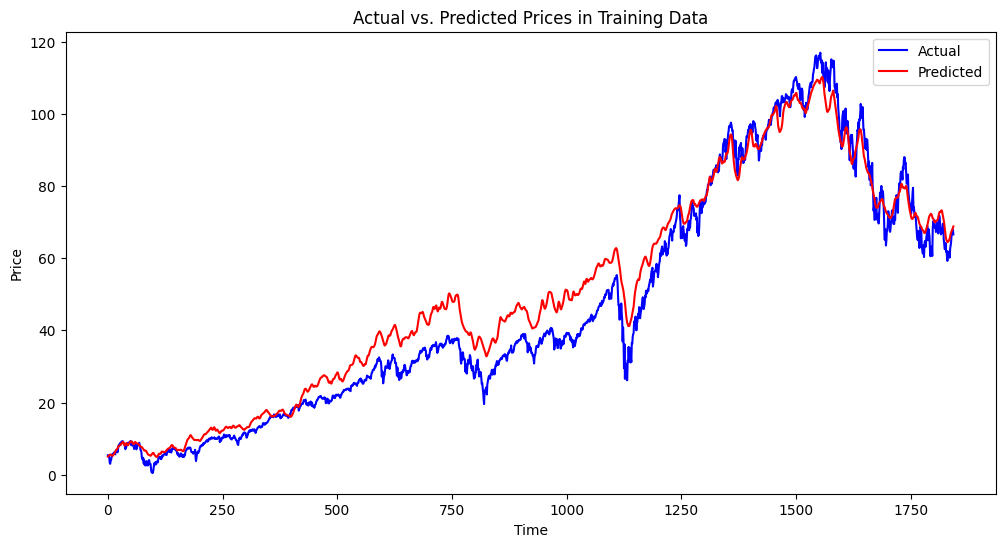

In [362]:
plt.figure(figsize=(12, 6))
plt.plot(y_train, label='Actual', color='blue')
plt.plot(y_pred_train, label='Predicted', color='red')
plt.title('Actual vs. Predicted Prices in Training Data')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [363]:
#ON TEST DATA
y_pred_test=model(test_x_tensor).cpu().detach().numpy()
y_pred_test=y_scalar.inverse_transform(y_pred_test)
y_test=y_scalar.inverse_transform(test_y_tensor[:,-1,:].cpu().detach().numpy())
mse=mean_squared_error(y_test,y_pred_test)
rmse=math.sqrt(mse)
mae=mean_absolute_error(y_test,y_pred_test)
r2=r2_score(y_test,y_pred_test)
print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R2: {r2}")

MSE: 239.7600555419922, RMSE: 15.484187274183691, MAE: 12.786736488342285, R2: 0.49906688928604126


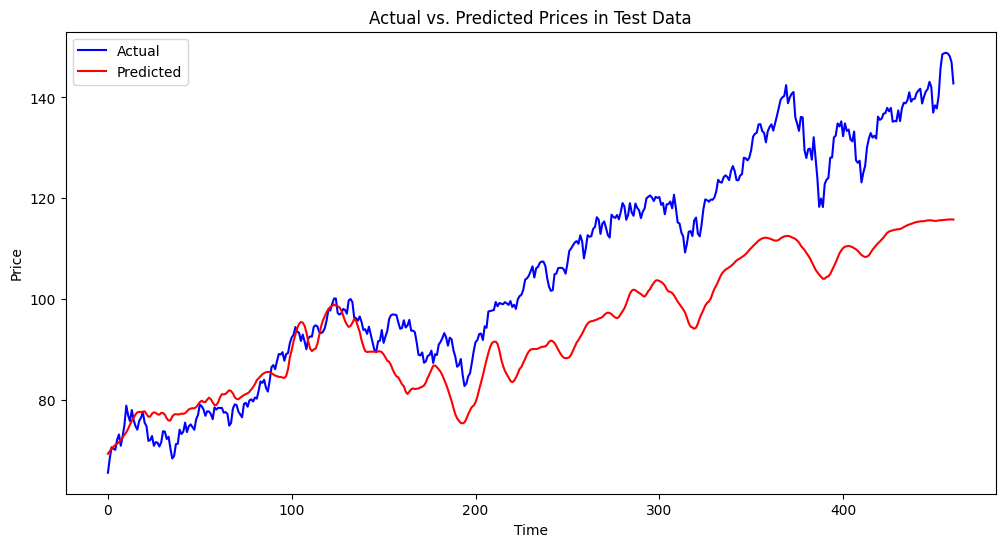

In [364]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred_test, label='Predicted', color='red')
plt.title('Actual vs. Predicted Prices in Test Data')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()